##Setup

In [1]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [2]:
!mkdir -p roberta_base
!gdown 1EmhxyCxnfvUia_KPLZeVoAjfB-TCp_uM -O roberta_base/train_embeddings_labels.zip
!gdown 1xXE1z69Jr7DL_Cp68hQEJfaYSTWgrQ0Y -O roberta_base/val_embeddings_labels.zip
!gdown 1GIPULlC5fXrzv2Kn-QrkSYJTeom5pxrh -O roberta_base/test_embeddings_labels.zip
!unzip -o roberta_base/train_embeddings_labels.zip -d roberta_base/
!unzip -o roberta_base/val_embeddings_labels.zip -d roberta_base/
!unzip -o roberta_base/test_embeddings_labels.zip -d roberta_base/


!mkdir -p roberta_finetuned
!gdown 1lUGbp17pVLy9NkDa830rzRhrqomn9IHC -O roberta_finetuned/train_embeddings_labels.zip
!gdown 14fgyoBQlSGq6x3ceUNzLHcFyHR-hTkuF -O roberta_finetuned/val_embeddings_labels.zip
!gdown 1oAaVRGehIHmkWkcEcdVvBbwNfqdNZlJd -O roberta_finetuned/test_embeddings_labels.zip
!unzip -o roberta_finetuned/train_embeddings_labels.zip -d roberta_finetuned/
!unzip -o roberta_finetuned/val_embeddings_labels.zip -d roberta_finetuned/
!unzip -o roberta_finetuned/test_embeddings_labels.zip -d roberta_finetuned/


Downloading...
From (original): https://drive.google.com/uc?id=1EmhxyCxnfvUia_KPLZeVoAjfB-TCp_uM
From (redirected): https://drive.google.com/uc?id=1EmhxyCxnfvUia_KPLZeVoAjfB-TCp_uM&confirm=t&uuid=6f36dab8-056e-4e25-9251-ba9434f9e335
To: /content/roberta_base/train_embeddings_labels.zip
100% 268M/268M [00:05<00:00, 48.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xXE1z69Jr7DL_Cp68hQEJfaYSTWgrQ0Y
To: /content/roberta_base/val_embeddings_labels.zip
100% 24.9M/24.9M [00:01<00:00, 21.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GIPULlC5fXrzv2Kn-QrkSYJTeom5pxrh
To: /content/roberta_base/test_embeddings_labels.zip
100% 23.8M/23.8M [00:01<00:00, 20.3MB/s]
Archive:  roberta_base/train_embeddings_labels.zip
 extracting: roberta_base/train_embeddings.npy  
 extracting: roberta_base/train_labels.npy  
Archive:  roberta_base/val_embeddings_labels.zip
 extracting: roberta_base/val_embeddings.npy  
 extracting: roberta_base/val_labels.npy  
Archive:  roberta_base/test_emb

## Embeddings Viz

In [3]:
PERPLEXITY = 50

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


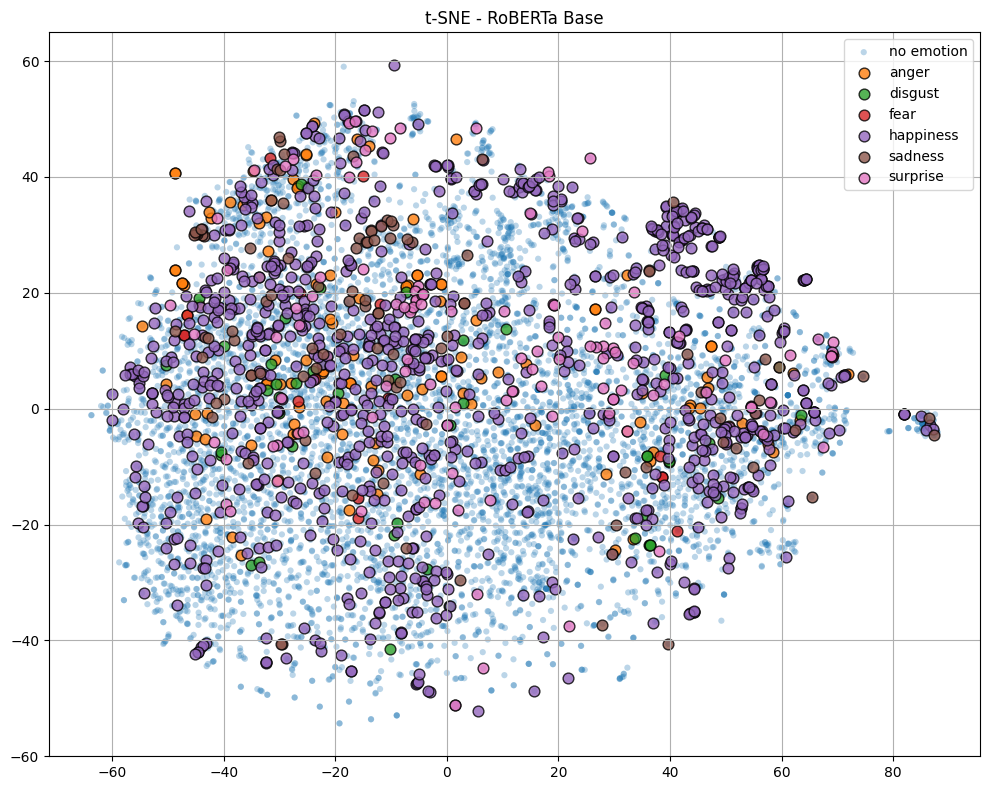

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Mapping from emotion ID to label
emotion_labels_full = {
    0: "no emotion",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}

# Load embeddings and labels
base_emb = np.load("roberta_base/test_embeddings.npy")
base_lbl = np.load("roberta_base/test_labels.npy")

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=PERPLEXITY, n_iter=1000)
base_2d = tsne.fit_transform(base_emb)

plt.figure(figsize=(10, 8))
for label in sorted(emotion_labels_full.keys()):
    idx = base_lbl == label
    size = 20 if label == 0 else 60
    alpha = 0.3 if label == 0 else 0.8
    edgecolor = "none" if label == 0 else "black"

    plt.scatter(
        base_2d[idx, 0],
        base_2d[idx, 1],
        label=emotion_labels_full[label],
        s=size,
        alpha=alpha,
        edgecolors=edgecolor
    )

plt.title("t-SNE - RoBERTa Base")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


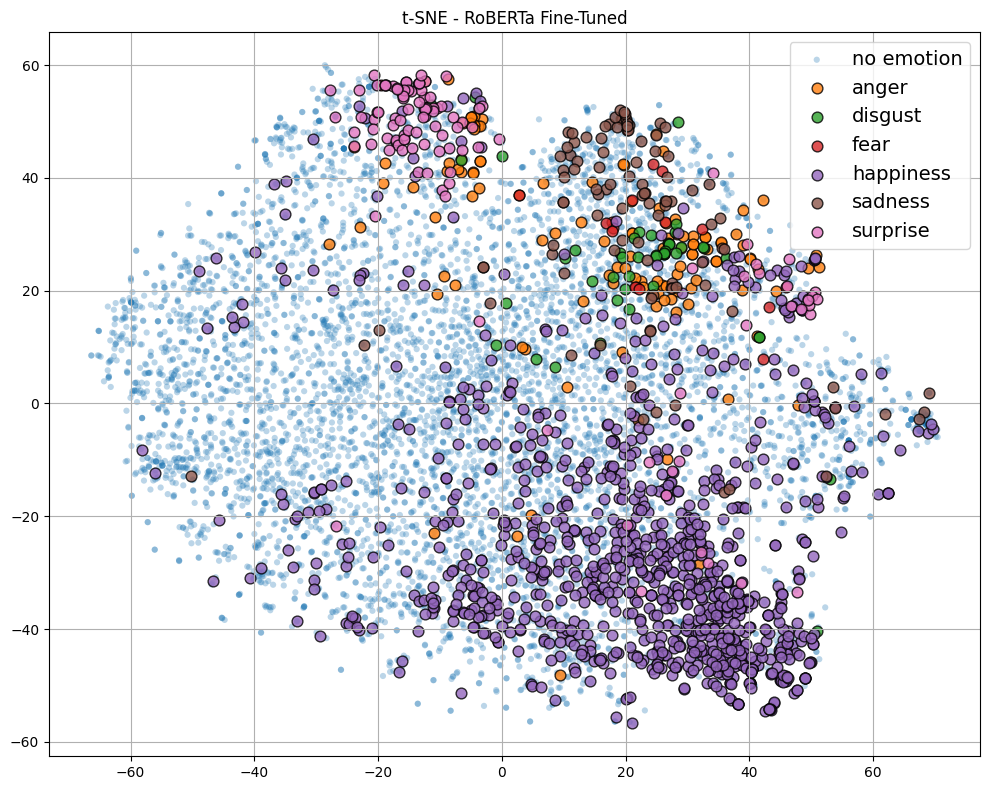

In [5]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

emotion_labels_full = {
    0: "no emotion",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}

ft_emb = np.load("roberta_finetuned/test_embeddings.npy")
ft_lbl = np.load("roberta_finetuned/test_labels.npy")

tsne = TSNE(n_components=2, random_state=42, perplexity=PERPLEXITY, n_iter=1000)
ft_2d = tsne.fit_transform(ft_emb)

plt.figure(figsize=(10, 8))
for label in sorted(emotion_labels_full.keys()):
    idx = ft_lbl == label
    size = 20 if label == 0 else 60
    alpha = 0.3 if label == 0 else 0.8
    edgecolor = "none" if label == 0 else "black"

    plt.scatter(
        ft_2d[idx, 0],
        ft_2d[idx, 1],
        label=emotion_labels_full[label],
        s=size,
        alpha=alpha,
        edgecolors=edgecolor
    )

plt.title("t-SNE - RoBERTa Fine-Tuned")
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
